# Stage 1 · Step 01 — Data setup and protocol verification

**A Computer Vision Project — *Flow Matching as a Layer*** · University of Haifa

---

Every accuracy number this project will ever report rests on one assumption: that the
datasets are loaded under the **exact protocol this project follows**. If the DTD
partition is wrong, or train and validation silently overlap, then every downstream
result is invalid — and invalid in a way that is invisible, because the numbers still
*look* reasonable. This notebook exists to make that assumption checkable instead of
assumed.

### What this notebook does

| # | Section | Output |
|---|---------|--------|
| 1 | Environment capture | `tables/environment.csv` |
| 2 | On-disk inventory | `tables/on_disk_inventory.csv` |
| 3 | Load the six official splits | — |
| 4 | **Protocol verification (20 assertions)** | `tables/protocol_checks.csv` |
| 5 | Split sizes | `tables/split_summary.csv`, `plots/split_sizes.png` |
| 6 | Per-class distribution | `tables/class_distribution_*.csv`, `plots/class_distribution_train.png` |
| 7 | Image geometry & centre-crop coverage | `tables/image_properties_*.csv`, `tables/centre_crop_coverage.csv`, 2 plots |
| 8 | FGVC-Aircraft copyright banner | `plots/aircraft_copyright_banner.png` |
| 9 | Visual sanity check | `plots/samples_dtd.png`, `plots/samples_aircraft.png` |
| 10 | K-shot feasibility | `tables/kshot_feasibility.csv`, `plots/kshot_training_sizes.png` |

### Protocol being verified

- **DTD** — all 47 classes, **official partition 1**
- **FGVC-Aircraft** — all 100 classes, **`variant`** annotation level (the fine-grained one)
- Official `train` / `val` / `test` splits, **never merged**
- Enough training images per class to support K ∈ {5, 10, full}

> **Runtime:** ~2 minutes. CPU only — no GPU needed at this step. No network access.

## 0 · Setup

The project ships a small installed package, **`cvlab`**, holding everything that would
otherwise be copy-pasted between notebooks: path resolution, dataset loading, the plot
style, and the artefact writers. So this notebook imports rather than redefines — there is
no `sys.path` juggling and no hardcoded directory anywhere in it.

If the import below fails, the package has not been installed yet:

```powershell
C:\cvlab_env\Scripts\python.exe -m pip install -e Stage_1
```

In [1]:
"""Stage 1 / Step 1 — local dataset verification."""
from __future__ import annotations

import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image

from cvlab.data import (
    DATASET_SPECS,
    SPLITS,
    class_counts,
    image_files,
    labels,
    load_datasets,
    missing_files,
)
from cvlab.paths import AIRCRAFT_ROOT, DATA_ROOT, STAGE1_ROOT, describe, step_dirs
from cvlab.plotting import DATASET_COLORS, SPLIT_COLORS, ArtifactWriter, apply_style

apply_style()
art = ArtifactWriter(*step_dirs("01_data_setup"))

print(describe())
print()
print(f"plots  -> {art.plots_dir}")
print(f"tables -> {art.tables_dir}")

Stage_1 root                   : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1  [ok]
Data root                      : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\Data  [ok]
DTD root (-> torchvision)      : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\Data  [ok]
Aircraft root (-> torchvision) : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\Data\FGVC-Aircraft  [ok]
Work root                      : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\Work  [ok]
Feature cache                  : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\features  [ok]
Results                        : C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\results  [ok]

plots  -> C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\Work\01_data_setup\plots
tables -> C:\Users\<user>\Project in Com

## 1 · Environment capture

Recorded so any number in this project can be traced back to the exact stack that produced
it. Printing them to the screen would let them vanish with the runtime, so they go
into a CSV that ships with the results.

This step is CPU-only, but the GPU is reported now because Step 2 will need it.

In [2]:
gpu_name, gpu_vram, cuda_build = "n/a", "n/a", "n/a"
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    gpu_name = props.name
    gpu_vram = f"{props.total_memory / 1024 ** 3:.1f} GB"
    cuda_build = torch.version.cuda

env_df = pd.DataFrame(
    [
        ("Platform", f"{platform.system()} {platform.release()}"),
        ("Python", sys.version.split()[0]),
        ("Interpreter", sys.executable),
        ("PyTorch", torch.__version__),
        ("torchvision", torchvision.__version__),
        ("CUDA (torch build)", cuda_build),
        ("CUDA available", str(torch.cuda.is_available())),
        ("GPU", gpu_name),
        ("GPU memory", gpu_vram),
        ("Project root", str(STAGE1_ROOT)),
    ],
    columns=["item", "value"],
)
art.table(env_df, "environment")
env_df

  saved table -> tables/environment.csv  (10 rows)


,item,value
0,Platform,Windows 10
1,Python,3.10.11
2,Interpreter,C:\cvlab_env\Scripts\python.exe
3,PyTorch,2.6.0+cu124
4,torchvision,0.21.0+cu124
5,CUDA (torch build),12.4
6,CUDA available,True
7,GPU,NVIDIA GeForce RTX 3050 Laptop GPU
8,GPU memory,4.0 GB
9,Project root,C:\Users\\Project in Computer Vision\Proj...


## 2 · On-disk inventory

Confirms the raw data is physically present and counts it, before any torchvision code
runs. If a download was truncated, this is where it shows up — as a JPEG count falling
short of the official 5,640 / 10,000.

In [3]:
DATASET_DIRS = {
    "DTD": DATA_ROOT / "dtd" / "dtd",
    "FGVC-Aircraft": AIRCRAFT_ROOT / "fgvc-aircraft-2013b",
}

disk_rows = []
for name, root in DATASET_DIRS.items():
    images = list(root.rglob("*.jpg"))
    total_bytes = sum(f.stat().st_size for f in images)
    disk_rows.append({
        "dataset": name,
        "root": str(root.relative_to(STAGE1_ROOT)),
        "exists": root.is_dir(),
        "n_jpg_found": len(images),
        "n_jpg_expected": DATASET_SPECS[name]["n_images"],
        "size_on_disk_GB": round(total_bytes / 1024 ** 3, 2),
        "mean_file_KB": round(total_bytes / max(len(images), 1) / 1024, 1),
    })

disk_df = pd.DataFrame(disk_rows)
art.table(disk_df, "on_disk_inventory")
disk_df

  saved table -> tables/on_disk_inventory.csv  (2 rows)


,dataset,root,exists,n_jpg_found,n_jpg_expected,size_on_disk_GB,mean_file_KB
0,DTD,Data\dtd\dtd,True,5640,5640,0.59,109.4
1,FGVC-Aircraft,Data\FGVC-Aircraft\fgvc-aircraft-2013b,True,10000,10000,2.57,269.7


## 3 · Load the six official splits

`cvlab.data.load_datasets()` wraps the two torchvision constructors with the protocol
already baked in, so the mandated arguments cannot be forgotten in a later notebook:

- `partition=1` — DTD ships **ten** different train/val/test partitions; this project fixes
  partition 1 throughout. Passing it explicitly means we never rely on a torchvision
  default that could change between versions.
- `annotation_level="variant"` — FGVC-Aircraft offers `manufacturer` (30 classes),
  `family` (70), and `variant` (100). Only `variant` is the fine-grained task this project
  targets.
- `download=False` — guarantees the notebook runs offline and can never silently
  re-download on top of a partially extracted folder.

Loading reads only the label text files, not the images, so it is near-instant.

In [4]:
t0 = time.time()
datasets = load_datasets()          # {dataset_name: {split: Dataset}}
dtd, aircraft = datasets["DTD"], datasets["FGVC-Aircraft"]

print(f"loaded 6 split objects in {time.time() - t0:.2f}s (label files only, no pixels read)\n")
for name, splits in datasets.items():
    sizes = "  ".join(f"{s}={len(d):5d}" for s, d in splits.items())
    print(f"{name:15s} {len(splits['train'].classes):3d} classes   {sizes}"
          f"   [{DATASET_SPECS[name]['note']}]")

print(f"\nDTD classes[:5]      {dtd['train'].classes[:5]}")
print(f"Aircraft classes[:5] {aircraft['train'].classes[:5]}")

loaded 6 split objects in 0.28s (label files only, no pixels read)

DTD              47 classes   train= 1880  val= 1880  test= 1880   [official partition 1]
FGVC-Aircraft   100 classes   train= 3334  val= 3333  test= 3333   [variant annotation level]

DTD classes[:5]      ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy']
Aircraft classes[:5] ['707-320', '727-200', '737-200', '737-300', '737-400']


## 4 · Protocol verification

The core of this notebook: **20 assertions** (10 per dataset). Each row is one claim about
the loaded data; the cell fails loudly if any of them breaks, so a protocol violation
cannot slip through into Step 2.

**The three checks we consider non-negotiable:**

- **Split disjointness.** Train and validation must never be merged. Trusting that
  torchvision got this right is not verification — we compare the actual image-path sets
  and require zero overlap. A train/test leak would inflate every reported accuracy while
  looking perfectly normal.
- **Files present on disk.** Split files are text and can reference images a partial
  extraction never wrote. Caught here rather than as a crash mid-way through Step 2.
- **K-shot feasibility.** The 10-shot setting silently requires *every* class to have at
  least 10 training images. Verified now, not discovered later.

The expected class counts and split sizes come from `cvlab.data.DATASET_SPECS`, so the
numbers we assert against live beside the loader rather than being retyped per notebook.

In [5]:
checks: list[dict] = []


def check(dataset: str, name: str, passed: bool, detail: str) -> None:
    checks.append({
        "dataset": dataset,
        "check": name,
        "status": "PASS" if passed else "FAIL",
        "detail": detail,
    })


for name, splits in datasets.items():
    spec = DATASET_SPECS[name]

    n_classes = len(splits["train"].classes)
    check(name, "class count", n_classes == spec["n_classes"],
          f"{n_classes} (expected {spec['n_classes']})")

    identical = splits["train"].classes == splits["val"].classes == splits["test"].classes
    check(name, "class list identical across splits", identical,
          "identical" if identical else "MISMATCH")

    for split in SPLITS:
        got, want = len(splits[split]), spec["split_sizes"][split]
        check(name, f"{split} split size", got == want, f"{got} (expected {want})")

    # Splits must never be merged - verify they really are disjoint.
    files = {s: set(image_files(splits[s])) for s in SPLITS}
    for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = files[a] & files[b]
        check(name, f"{a}/{b} disjoint", not overlap, f"{len(overlap)} shared images")

    # 10-shot needs >= 10 training images in every single class.
    min_per_class = min(class_counts(splits["train"]).values())
    check(name, "10-shot feasible (min >= 10 train imgs/class)", min_per_class >= 10,
          f"min {min_per_class} imgs/class")

    # Every referenced test image must actually exist on disk.
    missing = missing_files(splits["test"])
    check(name, "test files present on disk", not missing, f"{len(missing)} missing")

checks_df = pd.DataFrame(checks)
art.table(checks_df, "protocol_checks")

n_fail = int((checks_df["status"] == "FAIL").sum())
print(f"\n{len(checks_df) - n_fail}/{len(checks_df)} checks passed")
assert n_fail == 0, f"{n_fail} protocol check(s) FAILED - see the table above"
checks_df

  saved table -> tables/protocol_checks.csv  (20 rows)

20/20 checks passed


,dataset,check,status,detail
0,DTD,class count,PASS,47 (expected 47)
1,DTD,class list identical across splits,PASS,identical
2,DTD,train split size,PASS,1880 (expected 1880)
3,DTD,val split size,PASS,1880 (expected 1880)
4,DTD,test split size,PASS,1880 (expected 1880)
5,DTD,train/val disjoint,PASS,0 shared images
6,DTD,train/test disjoint,PASS,0 shared images
7,DTD,val/test disjoint,PASS,0 shared images
8,DTD,10-shot feasible (min >= 10 train imgs/class),PASS,min 40 imgs/class
9,DTD,test files present on disk,PASS,0 missing


## 5 · Split sizes

DTD is perfectly balanced by construction: 47 classes × 40 images × 3 splits = 5,640.
FGVC-Aircraft divides its 10,000 images into a near-thirds 3,334 / 3,333 / 3,333, which is
*not* perfectly balanced per class — an asymmetry inherent to the official split, and why
the per-class plot in the next section matters.

  saved table -> tables/split_summary.csv  (6 rows)


  saved plot  -> plots/split_sizes.png


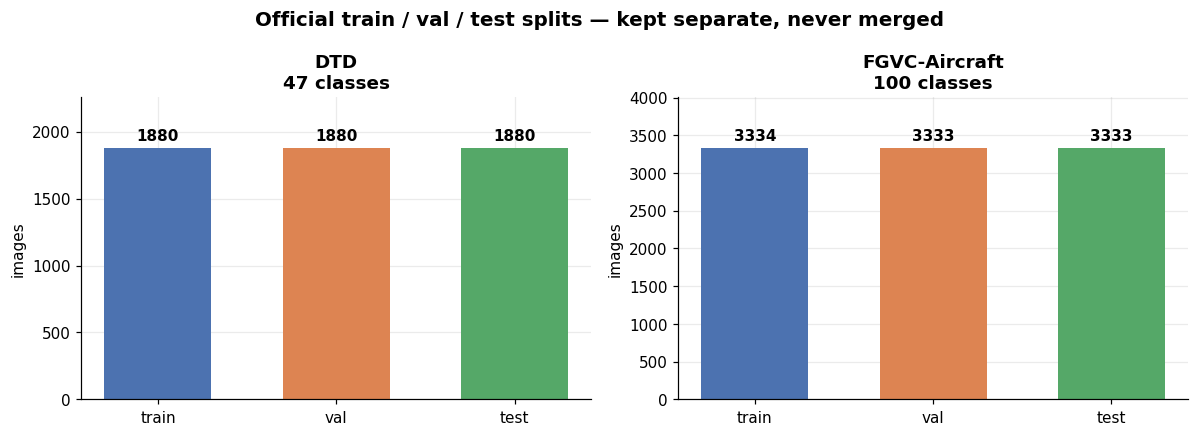

,dataset,split,n_images,n_classes,imgs_per_class
0,DTD,train,1880,47,40.00
1,DTD,val,1880,47,40.00
2,DTD,test,1880,47,40.00
3,FGVC-Aircraft,train,3334,100,33.34
4,FGVC-Aircraft,val,3333,100,33.33
5,FGVC-Aircraft,test,3333,100,33.33


In [6]:
size_df = pd.DataFrame([
    {
        "dataset": name,
        "split": split,
        "n_images": len(splits[split]),
        "n_classes": len(splits[split].classes),
        "imgs_per_class": round(len(splits[split]) / len(splits[split].classes), 2),
    }
    for name, splits in datasets.items()
    for split in SPLITS
])
art.table(size_df, "split_summary")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, datasets):
    sub = size_df[size_df["dataset"] == name]
    bars = ax.bar(sub["split"], sub["n_images"],
                  color=[SPLIT_COLORS[s] for s in sub["split"]], width=0.6)
    ax.bar_label(bars, fmt="%d", padding=3, fontweight="bold")
    ax.set_title(f"{name}\n{sub['n_classes'].iloc[0]} classes")
    ax.set_ylabel("images")
    ax.set_ylim(0, sub["n_images"].max() * 1.2)

fig.suptitle("Official train / val / test splits — kept separate, never merged",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "split_sizes")
plt.show()
size_df

## 6 · Per-class distribution

How many training images each class actually has, which determines what the K-shot
settings mean in practice:

- **DTD** — exactly 40 per class, so 5-shot uses 12.5% of the available training data and
  10-shot uses 25%.
- **FGVC-Aircraft** — 33–34 per class, so 5-shot uses 15% and 10-shot 30%.

The red dashed line marks the 10-image floor required by the 10-shot setting. Nothing may
fall below it.

  saved table -> tables/class_distribution_dtd.csv  (141 rows)
  saved table -> tables/class_distribution_fgvc_aircraft.csv  (300 rows)


  saved plot  -> plots/class_distribution_train.png


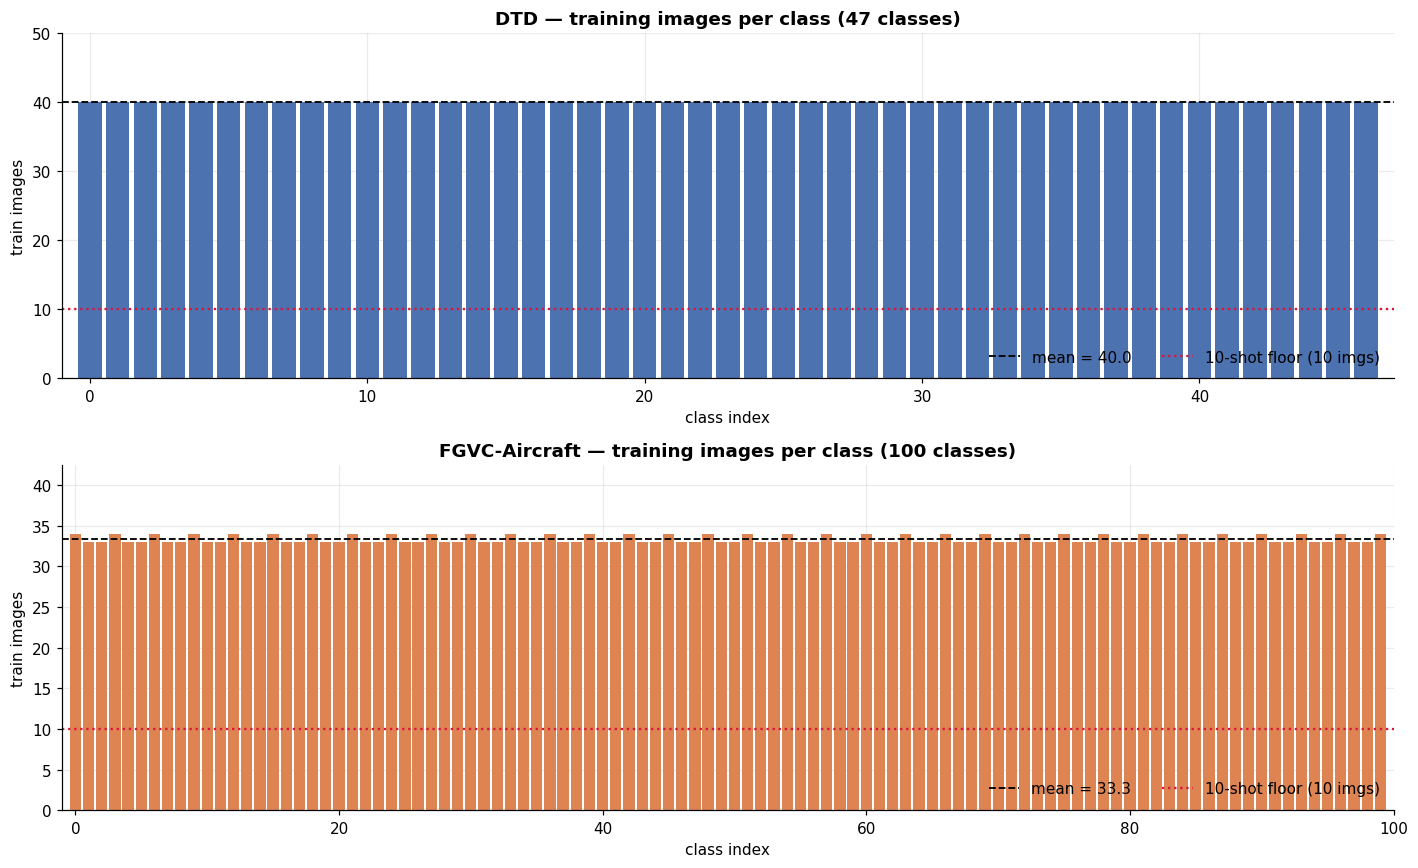

  saved table -> tables/class_balance_summary.csv  (6 rows)


,dataset,split,min,max,mean,std
0,DTD,test,40,40,40.00,0.00
1,DTD,train,40,40,40.00,0.00
2,DTD,val,40,40,40.00,0.00
3,FGVC-Aircraft,test,33,34,33.33,0.47
4,FGVC-Aircraft,train,33,34,33.34,0.48
5,FGVC-Aircraft,val,33,34,33.33,0.47


In [7]:
dist_frames: dict[str, pd.DataFrame] = {}

for name, splits in datasets.items():
    classes = splits["train"].classes
    rows = []
    for split in SPLITS:
        counts = class_counts(splits[split])
        rows.extend({
            "dataset": name,
            "split": split,
            "class_idx": idx,
            "class": cls,
            "n_images": counts.get(idx, 0),
        } for idx, cls in enumerate(classes))
    df = pd.DataFrame(rows)
    dist_frames[name] = df
    art.table(df, f"class_distribution_{name.lower().replace('-', '_')}")

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, (name, df) in zip(axes, dist_frames.items()):
    train = df[df["split"] == "train"].sort_values("class_idx")
    ax.bar(train["class_idx"], train["n_images"], color=DATASET_COLORS[name], width=0.85)
    mean_v = train["n_images"].mean()
    ax.axhline(mean_v, color="black", ls="--", lw=1.2, label=f"mean = {mean_v:.1f}")
    ax.axhline(10, color="crimson", ls=":", lw=1.5, label="10-shot floor (10 imgs)")
    ax.set_title(f"{name} — training images per class ({len(train)} classes)")
    ax.set_xlabel("class index")
    ax.set_ylabel("train images")
    ax.set_xlim(-1, len(train))
    ax.set_ylim(0, train["n_images"].max() * 1.25)
    ax.legend(loc="lower right", ncol=2)

fig.tight_layout()
art.figure(fig, "class_distribution_train")
plt.show()

balance_df = (
    pd.concat(dist_frames.values())
    .groupby(["dataset", "split"])["n_images"]
    .agg(["min", "max", "mean", "std"])
    .round(2)
    .reset_index()
)
art.table(balance_df, "class_balance_summary")
balance_df

## 7 · Image geometry

Both encoders in Step 2 resize the **shorter** side to 256 and centre-crop to 224×224.
Whether that is lossy depends on the source resolution and aspect ratio, so we measure
them rather than guess.

Read from JPEG headers only (Pillow does not decode pixels for `.size`), on a seeded
random sample of 1,500 images per dataset — enough for a stable distribution without
touching all 15,640 files.

**Watch the Aircraft aspect-ratio panel.** It is not a broad distribution like DTD's — it
is a spike at ≈1.47. Nearly every aircraft photo is the same wide landscape shape, which
has a concrete consequence quantified in the next cell.

  saved table -> tables/image_properties_sample.csv  (3000 rows)
  saved table -> tables/image_properties_summary.csv  (2 rows)


  saved plot  -> plots/image_geometry.png


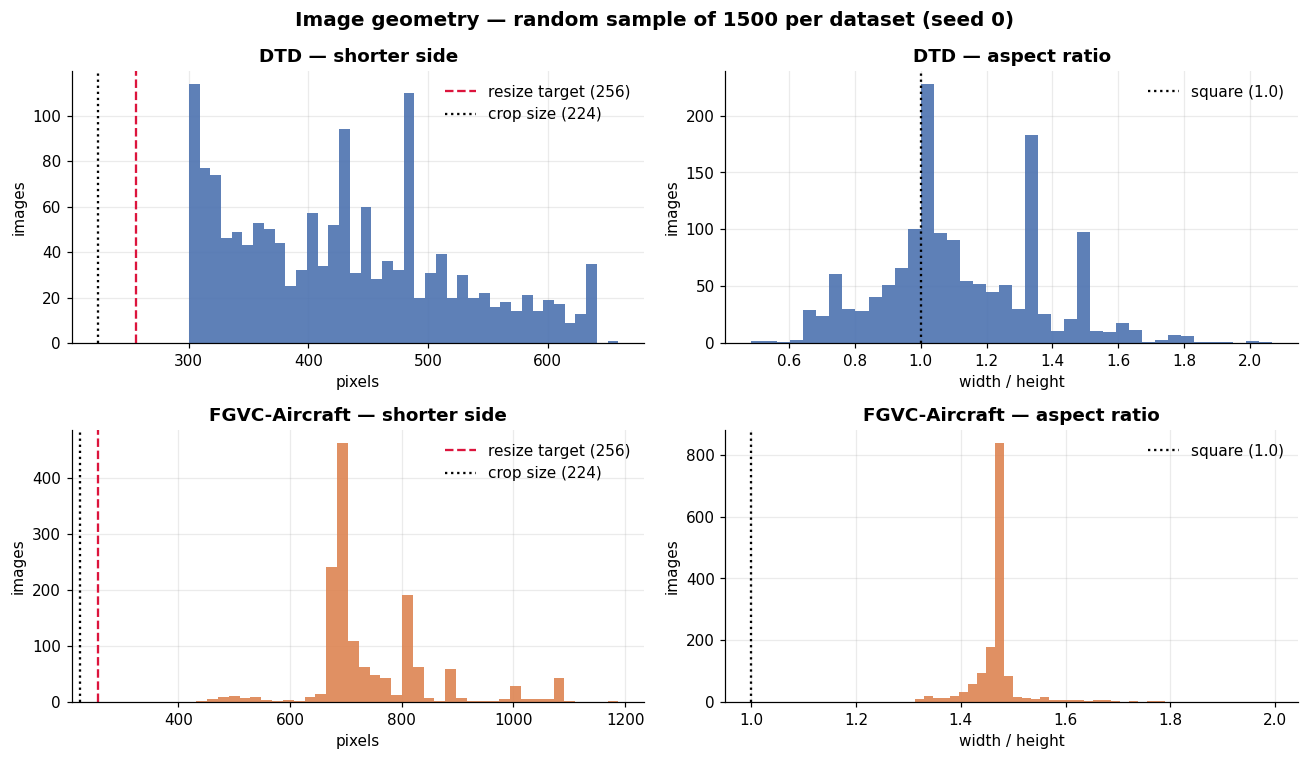

,dataset,n_sampled,width_min,width_max,height_min,height_max,min_side_min,min_side_median,aspect_min,aspect_max,modes
0,DTD,1500,300,800,300,670,300,425.5,0.485,2.067,RGB
1,FGVC-Aircraft,1500,779,1600,413,1188,413,700.0,1.312,1.994,RGB


In [8]:
RNG = np.random.default_rng(0)
SAMPLE_PER_DATASET = 1500

prop_rows = []
for name, splits in datasets.items():
    files = [p for split in SPLITS for p in image_files(splits[split])]
    take = RNG.choice(len(files), size=min(SAMPLE_PER_DATASET, len(files)), replace=False)
    for i in take:
        with Image.open(files[i]) as im:   # header only, no pixel decode
            w, h = im.size
            mode = im.mode
        prop_rows.append({
            "dataset": name, "width": w, "height": h,
            "aspect": round(w / h, 3), "min_side": min(w, h), "mode": mode,
        })

prop_df = pd.DataFrame(prop_rows)
art.table(prop_df, "image_properties_sample")

prop_summary = prop_df.groupby("dataset").agg(
    n_sampled=("width", "size"),
    width_min=("width", "min"), width_max=("width", "max"),
    height_min=("height", "min"), height_max=("height", "max"),
    min_side_min=("min_side", "min"), min_side_median=("min_side", "median"),
    aspect_min=("aspect", "min"), aspect_max=("aspect", "max"),
    modes=("mode", lambda s: ", ".join(sorted(s.unique()))),
).reset_index()
art.table(prop_summary, "image_properties_summary")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, (name, sub) in enumerate(prop_df.groupby("dataset")):
    ax = axes[row, 0]
    ax.hist(sub["min_side"], bins=40, color=DATASET_COLORS[name], alpha=0.9)
    ax.axvline(256, color="crimson", ls="--", lw=1.5, label="resize target (256)")
    ax.axvline(224, color="black", ls=":", lw=1.5, label="crop size (224)")
    ax.set_title(f"{name} — shorter side")
    ax.set_xlabel("pixels")
    ax.set_ylabel("images")
    ax.legend()

    ax = axes[row, 1]
    ax.hist(sub["aspect"], bins=40, color=DATASET_COLORS[name], alpha=0.9)
    ax.axvline(1.0, color="black", ls=":", lw=1.5, label="square (1.0)")
    ax.set_title(f"{name} — aspect ratio")
    ax.set_xlabel("width / height")
    ax.set_ylabel("images")
    ax.legend()

fig.suptitle(f"Image geometry — random sample of {SAMPLE_PER_DATASET} per dataset (seed 0)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "image_geometry")
plt.show()
prop_summary

### What the centre crop actually keeps

For a wide image, resizing the shorter side to 256 and then taking a 224 centre crop keeps
the full height but only part of the width. The cell below quantifies how much survives.

This matters far more for Aircraft than for DTD, for a reason specific to the subject
matter: aircraft are long, thin, horizontally-extended objects, and the fine details that
separate one *variant* from another — engine count and placement, wingtip shape, tail
geometry, fuselage length — sit near the horizontal extremes. A centre crop is exactly the
operation most likely to cut them off. For DTD the opposite holds: textures are
statistically uniform, so any crop is as representative as any other.

**We keep the standard preprocessing regardless.** The preprocessing associated with each
pretrained checkpoint is kept unchanged, since deviating would break comparability with the
pretrained encoders and with Stages 2–3. This is recorded as a known, quantified
limitation worth raising in discussion — not as a change to make.

  saved table -> tables/centre_crop_coverage.csv  (2 rows)


  saved plot  -> plots/centre_crop_coverage.png


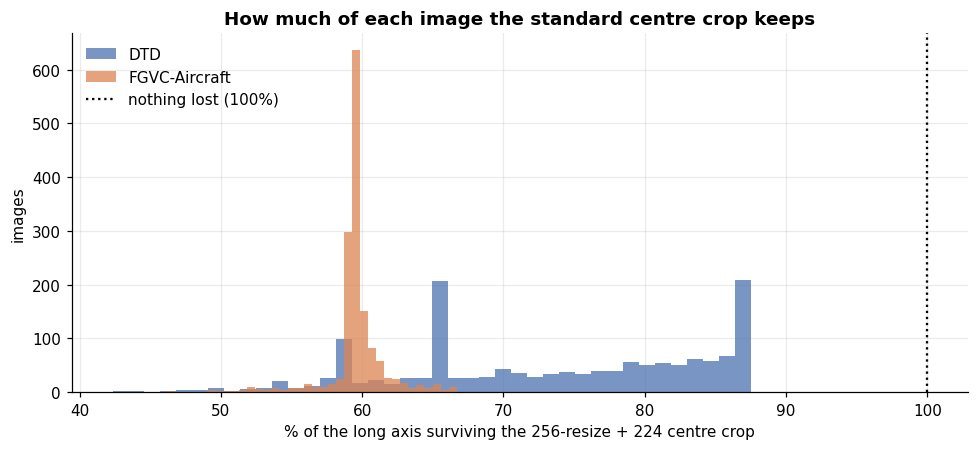

,dataset,median_aspect,median_long_axis_kept_%,median_long_axis_lost_%,images_losing_>25%,n_sampled
0,DTD,1.072,74.3,25.7,776,1500
1,FGVC-Aircraft,1.473,59.4,40.6,1500,1500


In [9]:
CROP_RATIO = 224 / 256  # centre crop taken after the shorter side is resized to 256

crop_rows = []
for name, sub in prop_df.groupby("dataset"):
    # After resizing the shorter side to 256, the longer side becomes 256 * long/short.
    long_over_short = np.maximum(sub["aspect"], 1 / sub["aspect"])
    kept_fraction = CROP_RATIO / long_over_short   # fraction of the long axis retained
    crop_rows.append({
        "dataset": name,
        "median_aspect": round(float(sub["aspect"].median()), 3),
        "median_long_axis_kept_%": round(float(kept_fraction.median()) * 100, 1),
        "median_long_axis_lost_%": round(100 - float(kept_fraction.median()) * 100, 1),
        "images_losing_>25%": int((kept_fraction < 0.75).sum()),
        "n_sampled": len(sub),
    })

crop_df = pd.DataFrame(crop_rows)
art.table(crop_df, "centre_crop_coverage")

fig, ax = plt.subplots(figsize=(9, 4.2))
for name, sub in prop_df.groupby("dataset"):
    long_over_short = np.maximum(sub["aspect"], 1 / sub["aspect"])
    ax.hist(100 * CROP_RATIO / long_over_short, bins=40, alpha=0.75,
            label=name, color=DATASET_COLORS[name])

ax.axvline(100, color="black", ls=":", lw=1.5, label="nothing lost (100%)")
ax.set_xlabel("% of the long axis surviving the 256-resize + 224 centre crop")
ax.set_ylabel("images")
ax.set_title("How much of each image the standard centre crop keeps")
ax.legend()
fig.tight_layout()
art.figure(fig, "centre_crop_coverage")
plt.show()
crop_df

## 8 · FGVC-Aircraft: the burned-in copyright banner

Every FGVC-Aircraft image carries a **20-pixel banner along the bottom edge** with a
copyright string rendered directly into the pixels. It is part of the dataset, not a
loading artefact.

This matters because it is *not* noise — it is a consistent, high-contrast, text-shaped
strip present in all 10,000 images. The standard practice for this dataset is to **crop the
bottom 20 px before any resizing**.

The red line marks that crop boundary; the bottom row zooms into the strip, where the
copyright text is plainly legible. Note the line lands exactly on the banner's top edge —
the 20 px figure is measured here, not assumed.

> **Decision for Step 2:** crop the banner before the resize/centre-crop pipeline. Left
> in place it survives into the 224×224 crop, so every aircraft feature vector would
> encode it. Since the banner is
> near-identical across classes it mostly wastes capacity rather than actively misleading,
> but removing it is free and strictly correct.

  saved plot  -> plots/aircraft_copyright_banner.png


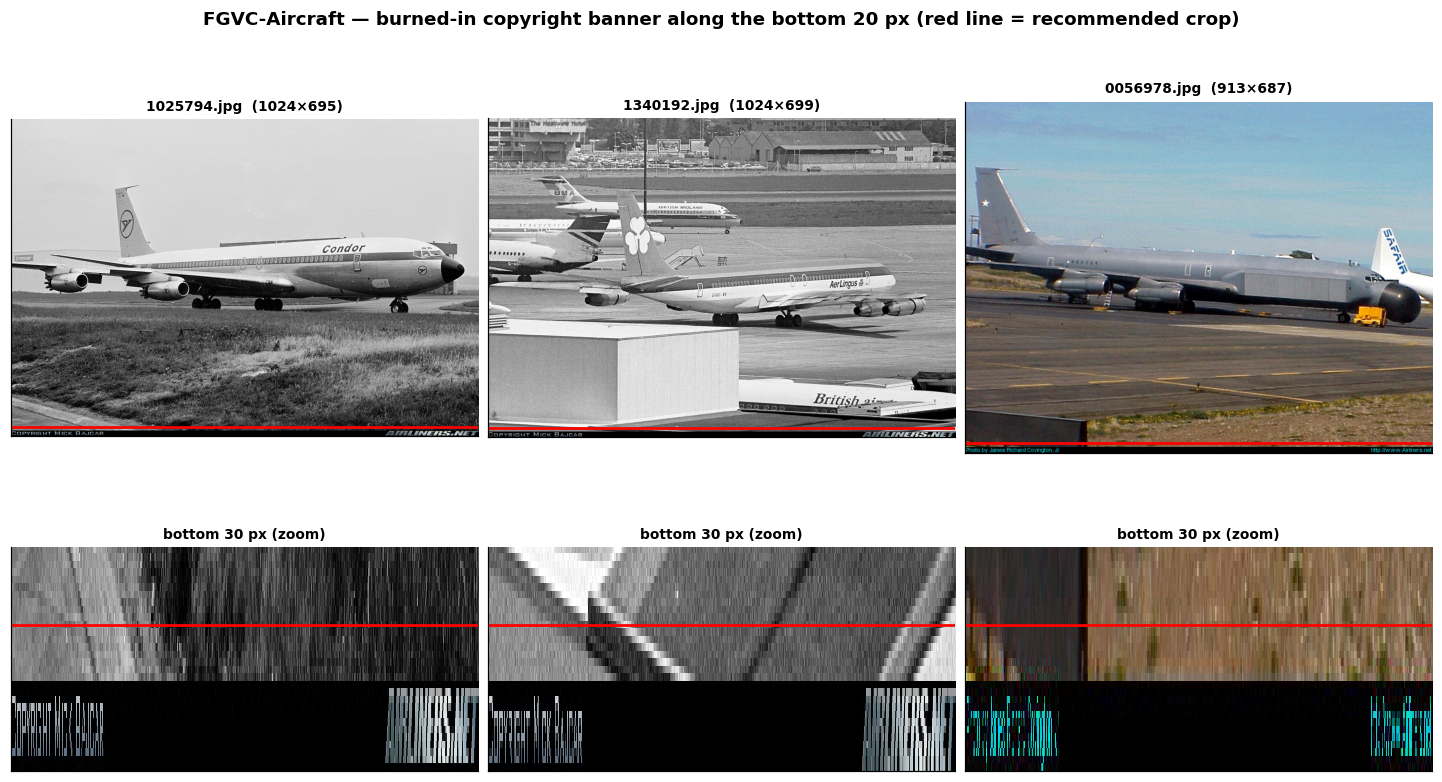

In [10]:
BANNER_PX = 20
ZOOM_PX = BANNER_PX + 10
sample_files = image_files(aircraft["train"])[:3]

fig, axes = plt.subplots(
    2, 3, figsize=(13, 7),
    gridspec_kw={"height_ratios": [3, 1.4]},
    layout="constrained",
)
for col, path in enumerate(sample_files):
    with Image.open(path) as im:
        arr = np.array(im)

    axes[0, col].imshow(arr)
    axes[0, col].axhline(arr.shape[0] - BANNER_PX, color="red", lw=1.8)
    axes[0, col].set_title(f"{Path(path).name}  ({arr.shape[1]}×{arr.shape[0]})", fontsize=9)

    axes[1, col].imshow(arr[-ZOOM_PX:], interpolation="nearest", aspect="auto")
    axes[1, col].axhline(ZOOM_PX - BANNER_PX, color="red", lw=1.8)
    axes[1, col].set_title(f"bottom {ZOOM_PX} px (zoom)", fontsize=9)

    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)

fig.suptitle("FGVC-Aircraft — burned-in copyright banner along the bottom 20 px "
             "(red line = recommended crop)", fontsize=12, fontweight="bold")
art.figure(fig, "aircraft_copyright_banner")
plt.show()

## 9 · Visual sanity check

The cheapest possible guard against a whole category of silent failure: a corrupted
extraction, a wrong split file, or labels shifted by one relative to images. All of those
produce plausible-looking *numbers* and obviously-wrong *pictures*.

For Aircraft in particular, the titles confirm the annotation level — these must read as
specific variants (`707-320`, `737-800`) rather than manufacturers (`Boeing`).

  saved plot  -> plots/samples_dtd.png


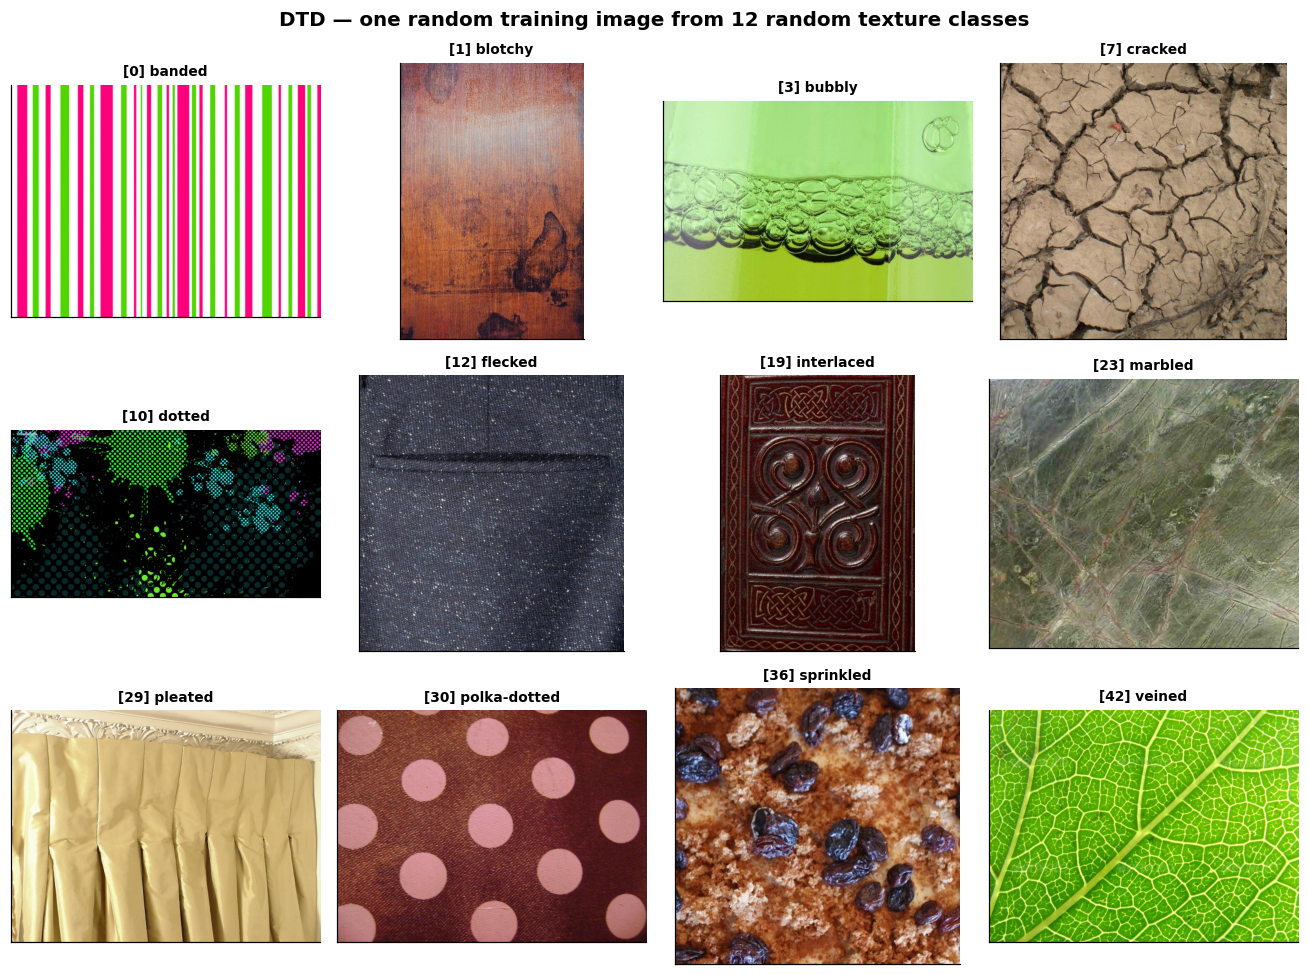

  saved plot  -> plots/samples_aircraft.png


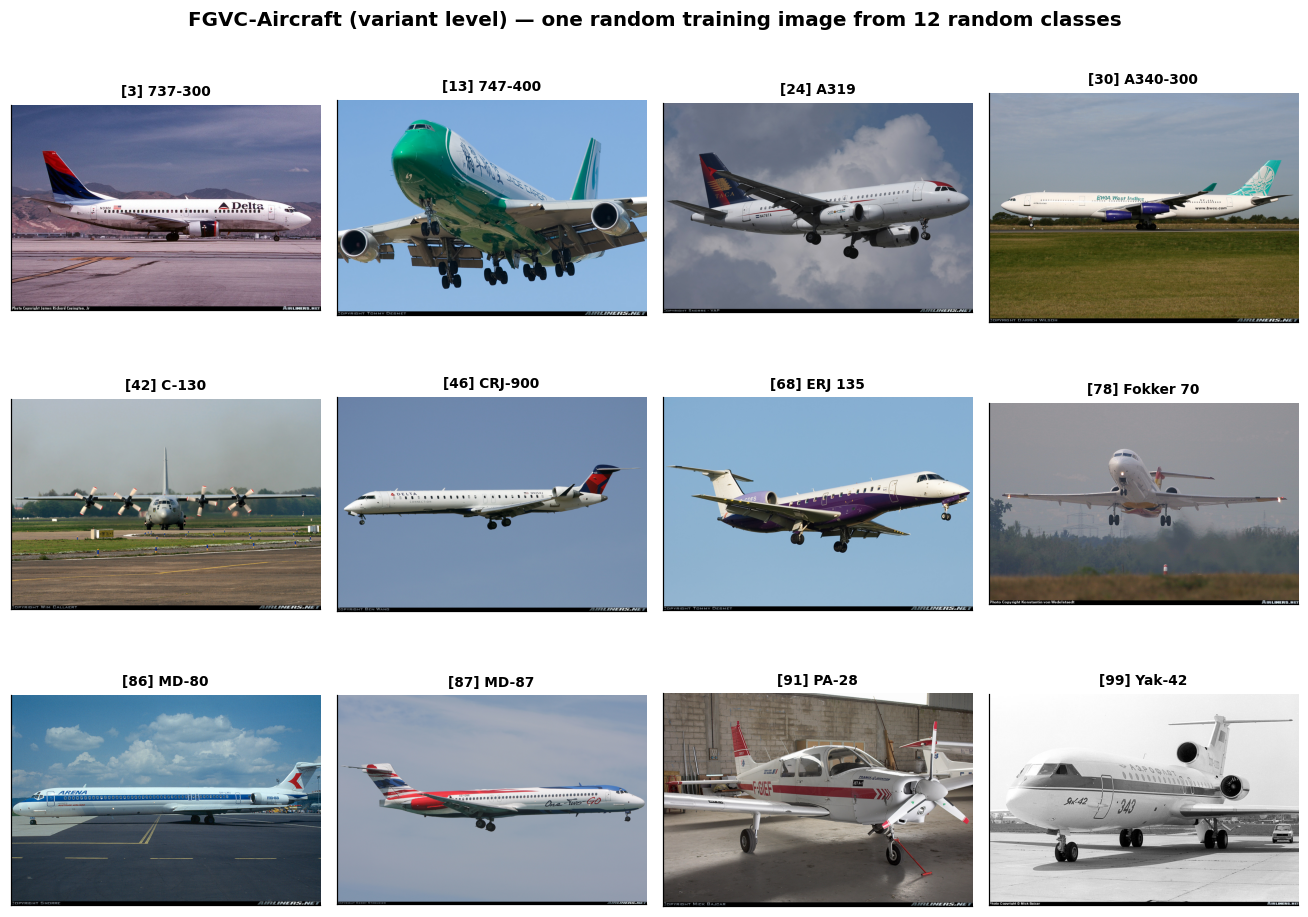

In [11]:
def sample_grid(splits: dict, title: str, fname: str, n_classes: int = 12, seed: int = 0):
    """One random training image from each of n_classes randomly chosen classes."""
    rng = np.random.default_rng(seed)
    ds = splits["train"]
    y = labels(ds)
    chosen = np.sort(rng.choice(len(ds.classes), size=n_classes, replace=False))

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, class_idx in zip(axes.ravel(), chosen):
        candidates = np.where(y == class_idx)[0]
        image, _ = ds[int(rng.choice(candidates))]
        ax.imshow(image)
        ax.set_title(f"[{class_idx}] {ds.classes[class_idx]}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    art.figure(fig, fname)
    plt.show()


sample_grid(dtd, "DTD — one random training image from 12 random texture classes",
            "samples_dtd", seed=0)
sample_grid(aircraft, "FGVC-Aircraft (variant level) — one random training image from 12 random classes",
            "samples_aircraft", seed=1)

## 10 · K-shot feasibility

Establishes exactly how large each training set will be in Steps 3 and 4, before any
classifier is trained.

For DTD the full setting is 8× the 5-shot setting, and for Aircraft it is 6.7× — enough
headroom that the three K settings stay clearly distinct from each other, which is what
makes the accuracy-versus-K comparison meaningful in the first place.

  saved table -> tables/kshot_feasibility.csv  (6 rows)


  saved plot  -> plots/kshot_training_sizes.png


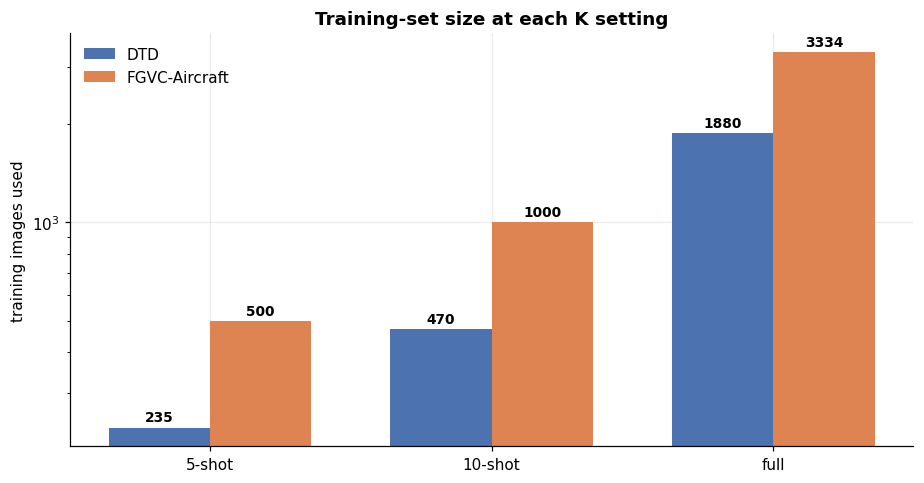

,dataset,K,classes_meeting_K,total_classes,min_available_per_class,subset_size,pct_of_full_train
0,DTD,5,47,47,40,235,12.5
1,DTD,10,47,47,40,470,25.0
2,DTD,full,47,47,40,1880,100.0
3,FGVC-Aircraft,5,100,100,33,500,15.0
4,FGVC-Aircraft,10,100,100,33,1000,30.0
5,FGVC-Aircraft,full,100,100,33,3334,100.0


In [12]:
kshot_rows = []
for name, splits in datasets.items():
    counts = pd.Series(class_counts(splits["train"])).sort_index()
    for K in (5, 10):
        kshot_rows.append({
            "dataset": name, "K": str(K),
            "classes_meeting_K": int((counts >= K).sum()),
            "total_classes": len(counts),
            "min_available_per_class": int(counts.min()),
            "subset_size": int(K * len(counts)),
            "pct_of_full_train": round(100 * K * len(counts) / counts.sum(), 1),
        })
    kshot_rows.append({
        "dataset": name, "K": "full",
        "classes_meeting_K": len(counts), "total_classes": len(counts),
        "min_available_per_class": int(counts.min()),
        "subset_size": int(counts.sum()), "pct_of_full_train": 100.0,
    })

kshot_df = pd.DataFrame(kshot_rows)
art.table(kshot_df, "kshot_feasibility")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
k_order = ["5", "10", "full"]
x = np.arange(len(k_order))
width = 0.36

for i, (name, color) in enumerate(DATASET_COLORS.items()):
    sub = kshot_df[kshot_df["dataset"] == name].set_index("K").loc[k_order]
    bars = ax.bar(x + (i - 0.5) * width, sub["subset_size"], width, label=name, color=color)
    ax.bar_label(bars, fmt="%d", padding=2, fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(["5-shot", "10-shot", "full"])
ax.set_ylabel("training images used")
ax.set_yscale("log")
ax.set_title("Training-set size at each K setting")
ax.legend()
fig.tight_layout()
art.figure(fig, "kshot_training_sizes")
plt.show()
kshot_df

## 11 · Artefact manifest

Everything this notebook wrote, in one table — so the next step and the final report can be
checked against a definitive list rather than a directory listing.

In [13]:
art.manifest()

19 artefacts in C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_1\Work\01_data_setup


,kind,file,size_KB
0,plot,plots/aircraft_copyright_banner.png,1173.3
1,plot,plots/centre_crop_coverage.png,44.8
2,plot,plots/class_distribution_train.png,79.6
3,plot,plots/image_geometry.png,102.2
4,plot,plots/kshot_training_sizes.png,29.2
5,plot,plots/samples_aircraft.png,2110.3
6,plot,plots/samples_dtd.png,2982.5
7,plot,plots/split_sizes.png,46.4
8,table,tables/centre_crop_coverage.csv,0.2
9,table,tables/class_balance_summary.csv,0.2


---

## Summary

All 20 protocol checks pass. The following are now **verified** rather than assumed:

| Protocol point | Status |
|---|---|
| DTD — 47 classes, official partition 1 | verified |
| FGVC-Aircraft — 100 classes, `variant` level | verified |
| Official train/val/test splits used | verified |
| Splits never merged (pairwise disjoint) | verified |
| Every referenced image present on disk | verified |
| K ∈ {5, 10, full} feasible for every class | verified |

### Findings carried into Step 2

1. **Crop the FGVC-Aircraft copyright banner** (bottom 20 px) before resizing. Free to do
   and strictly more correct.
2. **Source resolution is never the bottleneck** — the shorter side is ≥ 300 px for DTD and
   ≥ 413 px for Aircraft, both comfortably above the 256 resize target, so nothing is
   upscaled.
3. **The centre crop discards a real fraction of every aircraft image.** Aircraft photos
   cluster at an aspect ratio of ≈1.47, so the standard 256-resize + 224-crop keeps only
   about **59% of the horizontal extent**, and *every* sampled aircraft image loses more
   than 25% of its long axis. We keep the standard preprocessing associated with each
   checkpoint, but this is a genuine, quantified limitation and a strong explanation for
   why Aircraft accuracy is low.
4. **The datasets are near-balanced** (DTD exactly 40/class; Aircraft 33–34), so plain
   top-1 accuracy is a fair metric and no class weighting is needed.

### Next

**Step 02 — Feature extraction.** Load the frozen encoders (ResNet-18 on both datasets,
DINOv2 ViT-S/14 on Aircraft), run every image through exactly once, and cache the feature
tensors to `Stage_1/features/`. That is the last step that touches the images or the GPU in
any serious way — Steps 3–5 operate purely on cached vectors.

Three things to carry across, beyond the findings above:

- **Every transform must be defined at module level.** Windows starts DataLoader workers
  with the `spawn` method, which pickles the dataset and its transform, and a class defined
  *inside* a function cannot be pickled — which is what breaks `num_workers > 0` on
  Windows. Putting the transforms in `cvlab.encoders` instead of in a
  notebook cell keeps `num_workers > 0` available, and it turns out to be worth roughly a
  2× speed-up.
- Batch size 64 rather than 128, to stay well inside 4 GB of VRAM.
- Encoder construction and preprocessing belong in `cvlab/encoders.py`, so Steps 3–5 can
  reload the exact same transforms without copying them.